In [64]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
from scipy import stats
from scipy.stats import median_abs_deviation

In [65]:
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'figure.titlesize': 16,
    'axes.titlesize': 16,
    'axes.labelsize': 12,

    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',

    'legend.frameon': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.axisbelow': True
})

In [66]:
def format_plot(ax, title, xlabel, ylabel, horizontal=False):

    ax.set_title(title, pad=20)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if horizontal:
        ax.grid(axis='x', linestyle='--', alpha=0.5)
        ax.grid(axis='y', visible=False)
    else:
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        ax.grid(axis='x', visible=False)

In [67]:
def get_clean_mask(data, threshold=3.5):
    """
    Apply Iglewicz and Hoaglin's robust outlier detection.
    Returns: Boolean mask (True = Valid, False = Outlier)
    """
    median = np.median(data)
    mad = median_abs_deviation(data, scale='normal')
    modified_z_score = 0.6745 * (data - median) / mad
    return modified_z_score.abs() < threshold

def get_limits(data, sigma=3.5, min_floor=0.5, reference_col=None, cv_floor=0.015):
    """
    Calculates a ROBUST SYMMETRIC limit.
    Hybrid Mode: Supports both FIXED floors (e.g., 0.5 kg) and DYNAMIC floors (e.g., 1.5% of TBW).

    Args:
    - data (Series): The error/difference column.
    - sigma (float): Outlier threshold (default 3.5).
    - min_floor (float): The default HARD floor (used if reference_col is None).
    - reference_col (Series, Optional): The magnitude column (e.g., TBW).
      If provided, the floor becomes dynamic (Mean of Ref * cv_floor).
    - cv_floor (float): The percentage noise floor (default 1.5% = 0.015).
    """
    # 1. Clean Data (Drop NaNs)
    clean_data = data.dropna()

    # 2. Calculate Statistical Limit (MAD)
    # This captures the natural spread of your specific dataset
    mad = stats.median_abs_deviation(clean_data, scale=1.4826)
    stat_limit = sigma * mad

    # 3. Determine the Floor Strategy
    if reference_col is not None:
        # [DYNAMIC MODE] Floor = % of the Reference Magnitude
        # Align reference to clean_data indices to avoid size mismatch
        ref_clean = reference_col.loc[clean_data.index]
        floor_val = ref_clean.abs().mean() * cv_floor
    else:
        # [STATIC MODE] Floor = Fixed Number (Backwards Compatible)
        floor_val = min_floor

    # 4. Final Limit: The Greater of the Two
    # Prevents collapse on perfect data, but respects physics on noisy data.
    return max(stat_limit, floor_val)

In [68]:
def _Bland_Altman_comparison(dataframe, col_mean_raw, col_diff_raw, col_mean_fixed, col_diff_fixed, col_fix_bool):
    """
    Final Output:
    - Global Y-Limits (Honest Comparison).
    - Shaded Confidence Zones (Visual Clarity).
    - Logic: Green = 'Repaired' (Algorithm touched it).
    - Labels: 'Repaired Data', 'Difference (Method - Ref)', 'Mean (Repaired + Ref) / 2'.
    - Annotations: Top 5 Outliers labeled with IDs.
    """

    # Create local copy to avoid modifying original df
    df = dataframe.copy()

    # --- 1. GLOBAL LIMITS ---
    # Calculate limits from BOTH datasets so the Y-axis is identical
    y_all = pd.concat([df[col_diff_raw], df[col_diff_fixed]])
    y_max = y_all.max()
    y_min = y_all.min()
    y_range = y_max - y_min
    # Add 12% padding for labels
    y_lims = (y_min - y_range * 0.12, y_max + y_range * 0.12)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

    # Colors
    c_valid  = '#95a5a6' # Concrete Grey
    c_bad    = '#e74c3c' # Alizarin Red
    c_good   = '#27ae60' # Nephritis Green

    # Helper for Stats Box
    def add_stats_box(ax, data, loc='lower right'):
        mean = data.mean()
        sd = data.std()
        loa_up = mean + 1.96 * sd
        loa_low = mean - 1.96 * sd

        stats_text = (f"Bias: {mean:.2f}\n"
                      f"SD: {sd:.2f}\n"
                      f"LOA: [{loa_low:.2f}, {loa_up:.2f}]")
        at = AnchoredText(stats_text, prop=dict(size=10, fontfamily='monospace'),
                          frameon=True, loc=loc)
        at.patch.set_boxstyle("round,pad=0.2,rounding_size=0.2")
        at.patch.set_edgecolor('#dcdcdc')
        at.patch.set_alpha(0.95)
        ax.add_artist(at)
        return mean, loa_up, loa_low

    # ==========================================
    # PANEL A: RAW DATA
    # ==========================================
    mean_a, loa_up_a, loa_low_a = add_stats_box(ax1, df[col_diff_raw])

    # Identify Raw Outliers
    mask_outlier = (df[col_diff_raw] > loa_up_a) | (df[col_diff_raw] < loa_low_a)

    # Shaded Region (Safe Zone)
    ax1.axhspan(loa_low_a, loa_up_a, color=c_good, alpha=0.05, zorder=0)

    # Plot Points
    ax1.scatter(df.loc[~mask_outlier, col_mean_raw], df.loc[~mask_outlier, col_diff_raw],
                c=c_valid, alpha=0.5, s=40, label='Valid', zorder=1)
    # Slight transparency on red dots in Panel A to match Panel B's aesthetic
    ax1.scatter(df.loc[mask_outlier, col_mean_raw], df.loc[mask_outlier, col_diff_raw],
                c=c_bad, alpha=0.9, s=60, label='Outlier', zorder=2, edgecolors='white', linewidth=0.5)

    # Reference Lines
    ax1.axhline(mean_a, color='black', lw=1.5, zorder=3)
    ax1.axhline(loa_up_a, color='black', ls=':', lw=1.2, zorder=3)
    ax1.axhline(loa_low_a, color='black', ls=':', lw=1.2, zorder=3)

    # Labels Panel A
    ax1.set_title("A. Raw Data", pad=15)
    ax1.set_xlabel("Mean (Raw + Ref) / 2")
    ax1.set_ylabel("Difference (Method - Ref)")
    ax1.set_ylim(y_lims) # Force Global Scale

    # ==========================================
    # PANEL B: REPAIRED DATA
    # ==========================================
    mean_b, loa_up_b, loa_low_b = add_stats_box(ax2, df[col_diff_fixed])

    # --- LOGIC ---
    cond_outlier = (df[col_diff_fixed] > loa_up_b) | (df[col_diff_fixed] < loa_low_b)

    # Priority: 1. Algorithm Touched -> Green, 2. Else -> Red/Gray
    conditions = [
        df[col_fix_bool].astype(bool),
        cond_outlier,
    ]
    choices = ['Repaired', 'Unresolved']

    df['Status'] = np.select(conditions, choices, default='Valid')

    # --- PLOTTING ---

    # Layer 1: Valid Background (Pushed back)
    ax2.scatter(df.loc[df['Status']=='Valid', col_mean_fixed],
                df.loc[df['Status']=='Valid', col_diff_fixed],
                c=c_valid, alpha=0.2, s=40, zorder=1)

    # Layer 2: Action Data
    palette = {'Repaired': c_good, 'Unresolved': c_bad}
    markers = {'Repaired': 'X',    'Unresolved': 'P'}

    df_action = df[df['Status'].isin(palette.keys())].copy()

    if not df_action.empty:
        sns.scatterplot(data=df_action, x=col_mean_fixed, y=col_diff_fixed,
                        hue='Status', style='Status',
                        palette=palette, markers=markers,
                        s=100, edgecolor='white', linewidth=0.5,
                        ax=ax2, zorder=3)

    # Shaded Region
    ax2.axhspan(loa_low_b, loa_up_b, color=c_good, alpha=0.1, zorder=0)

    # Reference Lines
    ax2.axhline(mean_b, color='black', lw=1.5, zorder=3)
    ax2.axhline(loa_up_b, color=c_good, ls='--', lw=1.5, zorder=3)
    ax2.axhline(loa_low_b, color=c_good, ls='--', lw=1.5, zorder=3)

    # --- ANNOTATIONS (ENABLED) ---
    # Label top 5 worst Unresolved/Repaired points if they are outliers
    # We focus on 'Unresolved' first as they are critical errors
    df_bad = df[df['Status'] == 'Unresolved']

    if not df_bad.empty:
        top_fails = df_bad.reindex(
            df_bad[col_diff_fixed].abs().sort_values(ascending=False).index
        ).head(5)

        for idx, row in top_fails.iterrows():
            ax2.annotate(f"{idx}", (row[col_mean_fixed], row[col_diff_fixed]),
                         xytext=(0, 7), textcoords='offset points', ha='center',
                         fontsize=9, fontweight='bold', color=c_bad,
                         bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.7, ec="none"))

    # Labels Panel B
    ax2.set_title("B. Repaired Data", pad=15)
    ax2.set_xlabel("Mean (Repaired + Ref) / 2") # Matching Title

    # Clean Legend
    if ax2.get_legend():
        ax2.legend(title='', loc='upper right', framealpha=0.95)

    plt.tight_layout()
    plt.show()

In [69]:
filePath = '../Dataset/UCI_Gallstone_Dataset.csv'
df = pd.read_csv(filePath)

In [70]:
df_bioimpedance = df[[
    'Weight',
    'Total Body Water (TBW)',         # Measured in kg
    'Extracellular Water (ECW)',      # Measured in kg
    'Intracellular Water (ICW)',      # Measured in kg
    'Extracellular Fluid/Total Body Water (ECF/TBW)', # Derived Fluid Ratio
    'Total Body Fat Ratio (TBFR) (%)',# Percentage of total mass
    'Lean Mass (LM) (%)',             # Percentage of fat-free mass
    'Body Protein Content (Protein) (%)', # Protein composition percentage
    'Visceral Fat Rating (VFR)',      # Corresponds to "Visceral Adiposity Index" in text [cite: 61]
    'Bone Mass (BM)',                 # Measured in kg
    'Muscle Mass (MM)',               # Measured in kg
    'Obesity (%)',                    # Degree of obesity percentage
    'Total Fat Content (TFC)',        # Measured in kg
    'Visceral Fat Area (VFA)',        # Measured in kg
    'Visceral Muscle Area (VMA) (Kg)' # Measured in kg
]].copy()

In [71]:
# Track A: Physics (Summation) | TBW - (ECW + ICW)
col_TBW_calc_sum = 'TBW_calc_sum'
df_bioimpedance[col_TBW_calc_sum] = df_bioimpedance['Extracellular Water (ECW)'] + df_bioimpedance['Intracellular Water (ICW)']

col_TBW_disc_sum = 'TBW_disc_sum'
df_bioimpedance[col_TBW_disc_sum] = df_bioimpedance['Total Body Water (TBW)'] - df_bioimpedance[col_TBW_calc_sum]

# Track B: Logic (Ratio) | TBW - ECW / (Ratio/100)
col_TBW_calc_ratio = 'TBW_calc_ratio'
df_bioimpedance[col_TBW_calc_ratio] = df_bioimpedance['Extracellular Water (ECW)'] / (df_bioimpedance['Extracellular Fluid/Total Body Water (ECF/TBW)'] / 100)

col_TBW_disc_ratio = 'TBW_disc_ratio'
df_bioimpedance[col_TBW_disc_ratio] = df_bioimpedance['Total Body Water (TBW)'] - df_bioimpedance[col_TBW_calc_ratio]

# Track C: 4-Component Model | TBW - (Weight - Fat - Bone - Protein - 0.013*Weight)
epsilon_4C = df_bioimpedance['Weight']*0.013

col_TFC_calc_ratio = 'TFC_calc_ratio'
df_bioimpedance[col_TFC_calc_ratio] = (df_bioimpedance['Weight'] * (df_bioimpedance['Total Body Fat Ratio (TBFR) (%)'] / 100))

col_TPC_calc_ratio = 'TPC_calc_ratio'
df_bioimpedance[col_TPC_calc_ratio] = (df_bioimpedance['Weight'] * (df_bioimpedance['Body Protein Content (Protein) (%)'] / 100))

col_TBW_calc_4C = 'TBW_calc_4C'
df_bioimpedance[col_TBW_calc_4C] = df_bioimpedance['Weight'] - df_bioimpedance[col_TFC_calc_ratio] - df_bioimpedance['Bone Mass (BM)'] - df_bioimpedance[
    col_TPC_calc_ratio] - epsilon_4C

col_TBW_disc_4C = 'TBW_disc_4C'
df_bioimpedance[col_TBW_disc_4C] = df_bioimpedance['Total Body Water (TBW)'] - df_bioimpedance[col_TBW_calc_4C]

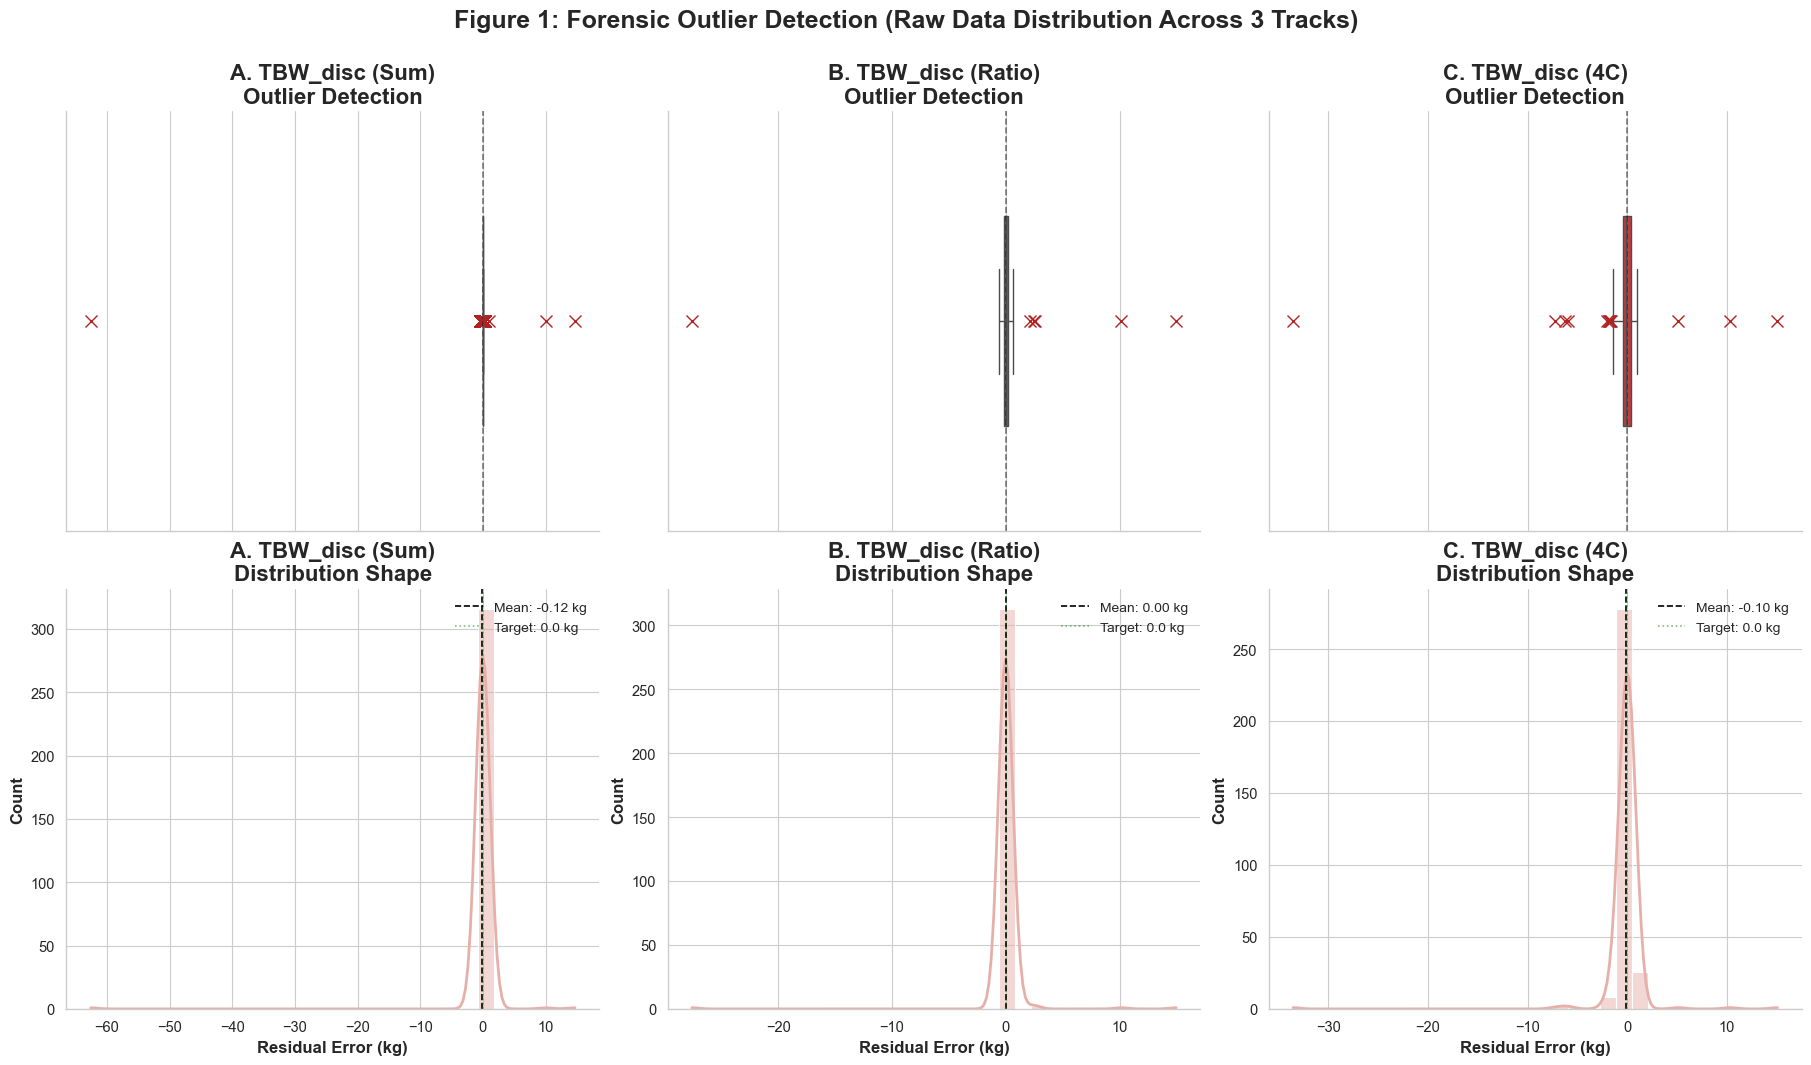

In [72]:
#(Figure 1: Distribution Analysis) ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True, sharex='col')

tracks = [
    ('A. TBW_disc (Sum)'    , col_TBW_disc_sum),
    ('B. TBW_disc (Ratio)'  , col_TBW_disc_ratio),
    ('C. TBW_disc (4C)'     , col_TBW_disc_4C)
]

for i, (title, col) in enumerate(tracks):
    data = df_bioimpedance[col]

    # Upper Plot: Boxplot
    sns.boxplot(x=data, ax=axes[0, i], color='tab:red', width=0.5,
                flierprops={"marker": "x", "markeredgecolor": "firebrick", "markersize": 8})
    axes[0, i].set_title(f"{title}\nOutlier Detection", fontweight='bold')
    axes[0, i].axvline(0, color='black', linestyle='--', alpha=0.5)

    # Lower Plot: Histogram
    # Safety Check: Prevent crash on empty columns
    if not data.isnull().all():
        sns.histplot(x=data, ax=axes[1, i], color='#E6B0AA', bins=30, kde=True,
                     line_kws={'linewidth': 2, 'color': 'firebrick'})

        mean_val = data.mean()
        axes[1, i].axvline(mean_val, color='black', linestyle='--', label=f'Mean: {mean_val:.2f} kg')
        axes[1, i].axvline(0, color='green', linestyle=':', alpha=0.5, label='Target: 0.0 kg')

    axes[1, i].set_title(f"{title}\nDistribution Shape", fontweight='bold')
    axes[1, i].set_xlabel("Residual Error (kg)")
    axes[1, i].legend(loc='upper right', fontsize=10)

plt.suptitle("Figure 1: Forensic Outlier Detection (Raw Data Distribution Across 3 Tracks)",
             y=1.05, fontsize=18, fontweight='bold')
plt.show()

In [73]:
# Uses 1.5% of the average TBW as the floor
TBW_disc_sum_lim_val = get_limits(
    df_bioimpedance[col_TBW_disc_sum],
    reference_col=df_bioimpedance['Total Body Water (TBW)']
)

TBW_disc_ratio_lim_val = get_limits(
    df_bioimpedance[col_TBW_disc_ratio],
    reference_col=df_bioimpedance['Total Body Water (TBW)']
)
#
#
# TBW_disc_sum_lim_val = get_limits(df_bioimpedance[col_TBW_disc_sum])
# TBW_disc_ratio_lim_val = get_limits(df_bioimpedance[col_TBW_disc_ratio])

# 2. GENERATE MASKS (Using the new symmetric limits)
TBW_disc_fit_sum_lim = (df_bioimpedance[col_TBW_disc_sum].abs() < TBW_disc_sum_lim_val)
TBW_disc_fit_ratio_lim = (df_bioimpedance[col_TBW_disc_ratio].abs() < TBW_disc_ratio_lim_val)

TBW_disc_fail_both_lim = ~TBW_disc_fit_sum_lim & ~TBW_disc_fit_ratio_lim
TBW_disc_fail_ratio_lim = TBW_disc_fit_sum_lim & ~TBW_disc_fit_ratio_lim
TBW_disc_fail_sum_lim = ~TBW_disc_fit_sum_lim & TBW_disc_fit_ratio_lim
TBW_disc_fit_both_lim = TBW_disc_fit_sum_lim & TBW_disc_fit_ratio_lim

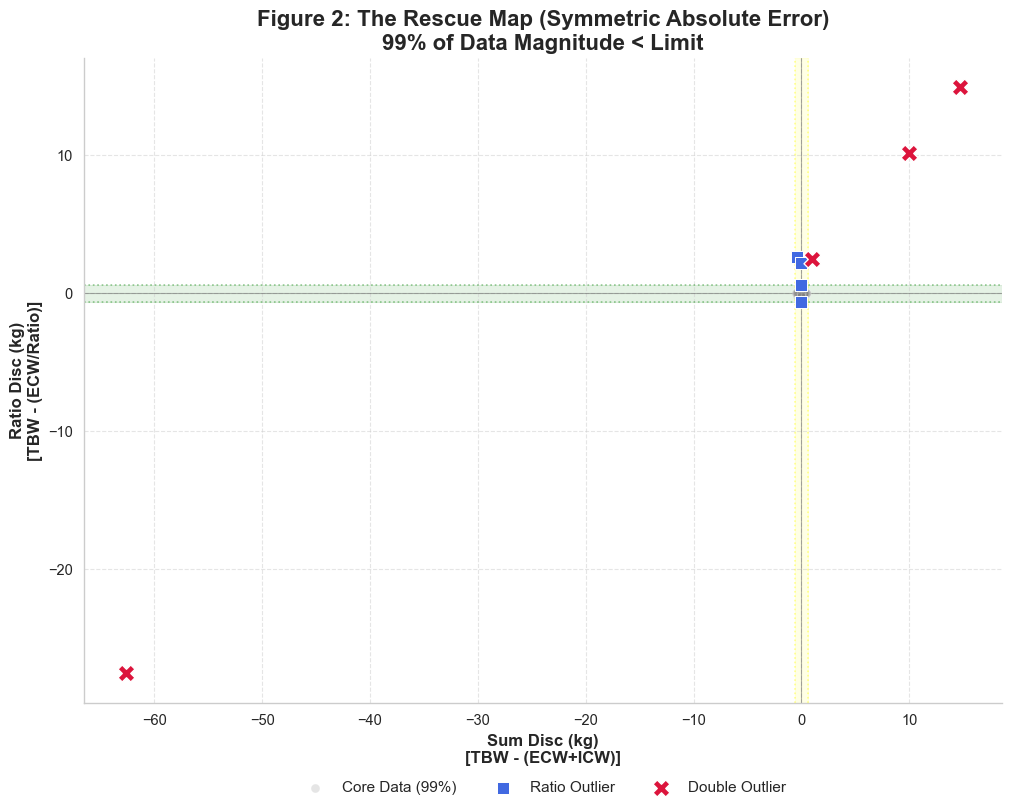

In [74]:
# --- 2. Figure 2: The Rescue Map (Symmetric Absolute Percentiles) ---
fig2, ax2 = plt.subplots(figsize=(10, 8), constrained_layout=True)

# A. DRAW THE ZONES (Perfectly Centered Cross)
ax2.axvspan(-TBW_disc_sum_lim_val, TBW_disc_sum_lim_val, color='yellow', alpha=0.1, zorder=0)
ax2.axhspan(-TBW_disc_ratio_lim_val, TBW_disc_ratio_lim_val, color='green', alpha=0.1, zorder=0)

# Dotted boundaries for visibility
ax2.axvline(-TBW_disc_sum_lim_val, color='yellow', linestyle=':', alpha=0.4)
ax2.axvline(TBW_disc_sum_lim_val, color='yellow', linestyle=':', alpha=0.4)
ax2.axhline(-TBW_disc_ratio_lim_val, color='green', linestyle=':', alpha=0.4)
ax2.axhline( TBW_disc_ratio_lim_val, color='green', linestyle=':', alpha=0.4)

# Center lines
ax2.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.3, zorder=1)
ax2.axvline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.3, zorder=1)

# B. SCATTER PLOTS
sns.scatterplot(data=df_bioimpedance[TBW_disc_fit_both_lim], x=col_TBW_disc_sum, y=col_TBW_disc_ratio,
                color='gray', alpha=0.2, s=40, label=f'Core Data (99%)', ax=ax2, zorder=2)

sns.scatterplot(data=df_bioimpedance[TBW_disc_fail_ratio_lim], x=col_TBW_disc_sum, y=col_TBW_disc_ratio,
                color='royalblue', s=80, marker='s', label='Ratio Outlier', ax=ax2, zorder=3)

sns.scatterplot(data=df_bioimpedance[TBW_disc_fail_sum_lim], x=col_TBW_disc_sum, y=col_TBW_disc_ratio,
                color='darkorange', s=80, marker='^', label='Sum Outlier', ax=ax2, zorder=4)

sns.scatterplot(data=df_bioimpedance[TBW_disc_fail_both_lim], x=col_TBW_disc_sum, y=col_TBW_disc_ratio,
                color='crimson', s=150, marker='X', label='Double Outlier', ax=ax2, zorder=5)

ax2.set_title(f"Figure 2: The Rescue Map (Symmetric Absolute Error)\n99% of Data Magnitude < Limit",
              fontweight='bold', fontsize=16)
ax2.set_xlabel("Sum Disc (kg)\n[TBW - (ECW+ICW)]", fontweight='bold')
ax2.set_ylabel("Ratio Disc (kg)\n[TBW - (ECW/Ratio)]", fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.5, zorder=0)

ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1),
           ncol=3, frameon=False, fontsize=11)

plt.show()

In [75]:
# Fixing TBW column
col_TBW_fixed = 'TBW_fixed'
df_bioimpedance[col_TBW_fixed] = df_bioimpedance['Total Body Water (TBW)']
col_TBW_fix_status = 'TBW_fixed_status'
df_bioimpedance[col_TBW_fix_status] = False

# CASE 1: Ratio Failed -> Use Sum
df_bioimpedance.loc[TBW_disc_fail_ratio_lim, col_TBW_fixed] = df_bioimpedance.loc[TBW_disc_fail_ratio_lim, col_TBW_calc_sum]
df_bioimpedance.loc[TBW_disc_fail_ratio_lim, col_TBW_fix_status] = True

# CASE 2: Sum Failed -> Use Ratio
df_bioimpedance.loc[TBW_disc_fail_sum_lim, col_TBW_fixed] = df_bioimpedance.loc[TBW_disc_fail_sum_lim, col_TBW_calc_ratio]
df_bioimpedance.loc[TBW_disc_fail_sum_lim, col_TBW_fix_status] = True

# === CASE 3: Both Failed -> Fallback to Ratio ===
df_bioimpedance.loc[TBW_disc_fail_both_lim, col_TBW_fixed] = df_bioimpedance.loc[TBW_disc_fail_both_lim, col_TBW_calc_ratio]
df_bioimpedance.loc[TBW_disc_fail_both_lim, col_TBW_fix_status] = True

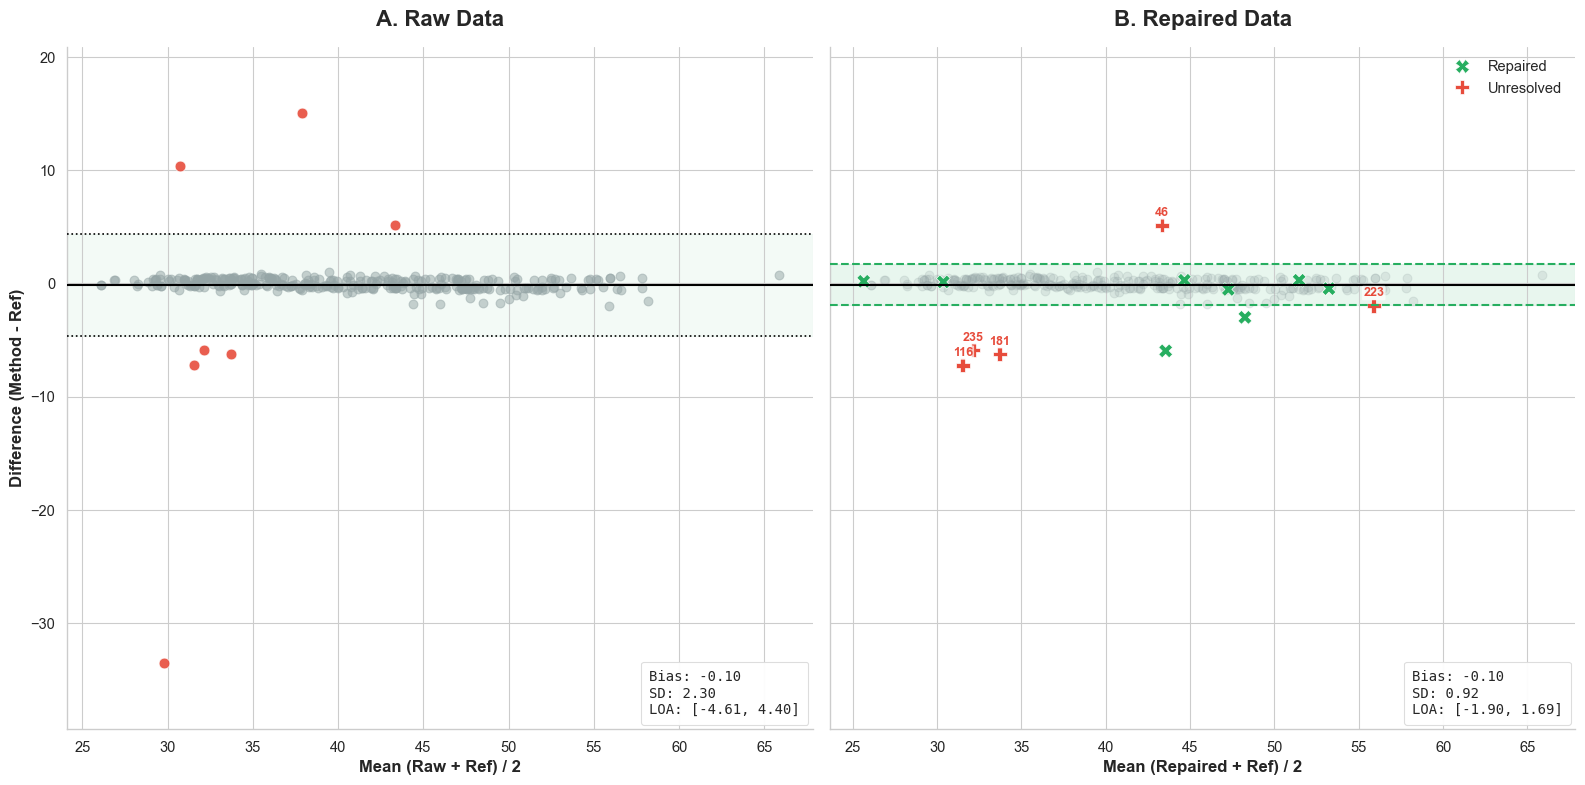

In [76]:
col_TBW_mean_raw = 'TBW_mean_raw'
df_bioimpedance[col_TBW_mean_raw] = (df_bioimpedance['Total Body Water (TBW)'] + df_bioimpedance[col_TBW_calc_4C]) / 2
col_TBW_diff_raw = 'TBW_diff_raw'
df_bioimpedance[col_TBW_diff_raw] = df_bioimpedance['Total Body Water (TBW)'] - df_bioimpedance[col_TBW_calc_4C]
col_TBW_mean_fixed = 'TBW_mean_fixed'
df_bioimpedance[col_TBW_mean_fixed] = (df_bioimpedance[col_TBW_fixed] + df_bioimpedance[col_TBW_calc_4C]) / 2
col_TBW_diff_fixed = 'TBW_diff_fixed'
df_bioimpedance[col_TBW_diff_fixed] = df_bioimpedance[col_TBW_fixed] - df_bioimpedance[col_TBW_calc_4C]

_Bland_Altman_comparison(df_bioimpedance,col_TBW_mean_raw,col_TBW_diff_raw,col_TBW_mean_fixed,col_TBW_diff_fixed,col_TBW_fix_status)

In [77]:
col_TFC_calc_lean = 'TFC_calc_lean'
df_bioimpedance[col_TFC_calc_lean] = df_bioimpedance['Weight'] - (df_bioimpedance['Weight'] * df_bioimpedance['Lean Mass (LM) (%)'] / 100)

col_TFC_disc_lean = 'TFC_disc_lean'
df_bioimpedance[col_TFC_disc_lean] = df_bioimpedance['Total Fat Content (TFC)'] - df_bioimpedance[col_TFC_calc_lean]

col_TFC_calc_ratio = 'TFC_calc_ratio'
df_bioimpedance[col_TFC_calc_ratio] = (df_bioimpedance['Weight'] * (df_bioimpedance['Total Body Fat Ratio (TBFR) (%)'] / 100))

col_TFC_disc_ratio = 'TFC_disc_ratio'
df_bioimpedance[col_TFC_disc_ratio] = df_bioimpedance['Total Fat Content (TFC)'] - df_bioimpedance[col_TFC_calc_ratio]

col_TFC_calc_sumOfRatio = 'TFC_calc_sumOfRatio'
df_bioimpedance[col_TFC_calc_sumOfRatio] = df_bioimpedance['Lean Mass (LM) (%)'] + df_bioimpedance['Total Body Fat Ratio (TBFR) (%)']

col_TFC_disc_sumOfRatio = 'TFC_disc_sumOfRatio'
df_bioimpedance[col_TFC_disc_sumOfRatio] = 100 - df_bioimpedance[col_TFC_calc_sumOfRatio]

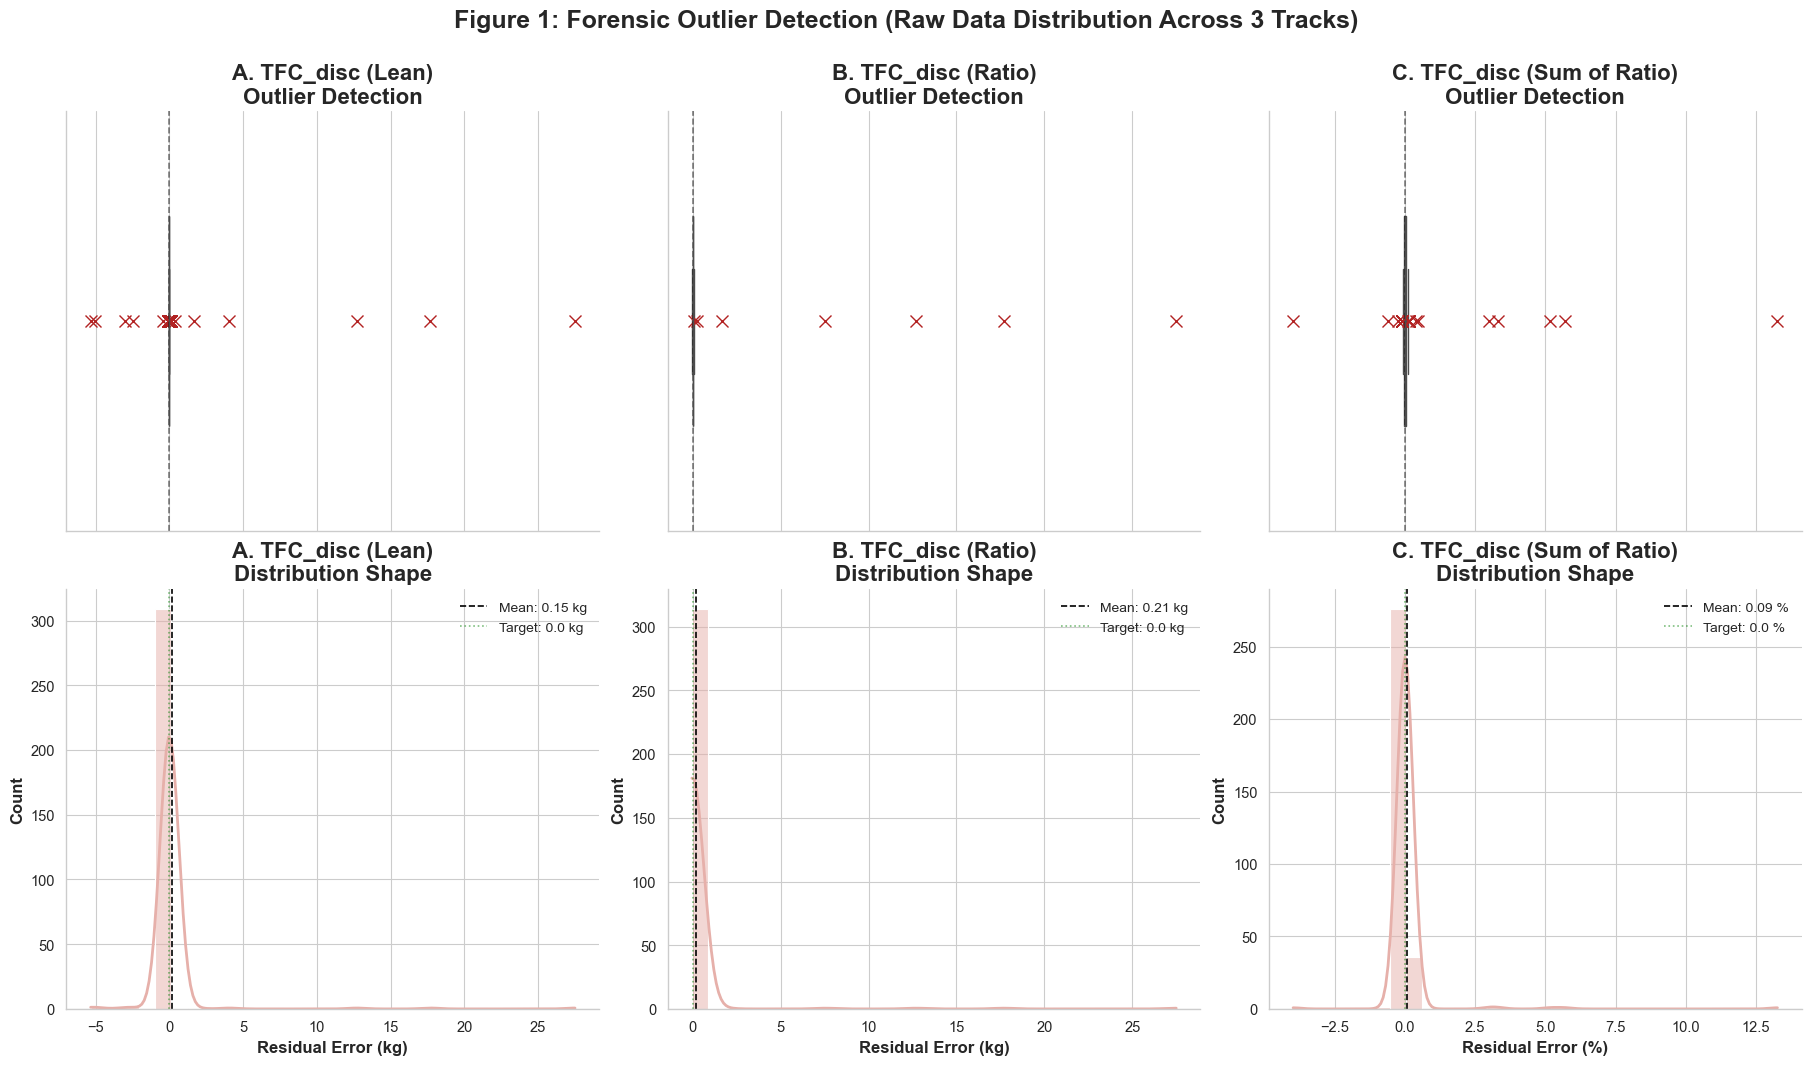

In [78]:
  #(Figure 1: Distribution Analysis) ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True, sharex='col')

tracks = [
    ('A. TFC_disc (Lean)'   , col_TFC_disc_lean),
    ('B. TFC_disc (Ratio)'  , col_TFC_disc_ratio),
    ('C. TFC_disc (Sum of Ratio)'     , col_TFC_disc_sumOfRatio)
]

for i, (title, col) in enumerate(tracks):
    data = df_bioimpedance[col]

    # --- DYNAMIC UNIT LOGIC ---
    # If we are on the 3rd column (index 2), use %, otherwise use kg.
    is_percent_col = (i == 2)
    unit = "%" if is_percent_col else "kg"
    target_val = 0.0

    # 1. Upper Plot: Boxplot
    sns.boxplot(x=data, ax=axes[0, i], color='tab:red', width=0.5,
                flierprops={"marker": "x", "markeredgecolor": "firebrick", "markersize": 8})
    axes[0, i].set_title(f"{title}\nOutlier Detection", fontweight='bold')
    axes[0, i].axvline(0, color='black', linestyle='--', alpha=0.5)

    # 2. Lower Plot: Histogram
    if not data.isnull().all():
        sns.histplot(x=data, ax=axes[1, i], color='#E6B0AA', bins=30, kde=True,
                     line_kws={'linewidth': 2, 'color': 'firebrick'})

        mean_val = data.mean()

        # FIX: Draw lines on the CURRENT axis (axes[1, i]), not axes[1, 2]
        axes[1, i].axvline(mean_val, color='black', linestyle='--',
                           label=f'Mean: {mean_val:.2f} {unit}')
        axes[1, i].axvline(target_val, color='green', linestyle=':', alpha=0.5,
                           label=f'Target: {target_val} {unit}')

    # 3. Labeling
    axes[1, i].set_title(f"{title}\nDistribution Shape", fontweight='bold')
    axes[1, i].set_xlabel(f"Residual Error ({unit})") # Dynamic Label
    axes[1, i].legend(loc='upper right', fontsize=10)

plt.suptitle("Figure 1: Forensic Outlier Detection (Raw Data Distribution Across 3 Tracks)",
             y=1.05, fontsize=18, fontweight='bold')
plt.show()

In [79]:
TFC_disc_lean_lim_val = get_limits(df_bioimpedance[col_TFC_disc_lean],reference_col=df_bioimpedance['Total Fat Content (TFC)'])
TFC_disc_ratio_lim_val = get_limits(df_bioimpedance[col_TFC_disc_ratio],reference_col=df_bioimpedance['Total Fat Content (TFC)'])
TFC_disc_sumOfRatio_lim_val = 1

# 2. GENERATE MASKS (Using the new symmetric limits)
TFC_disc_fit_lean_lim   = (df_bioimpedance[col_TFC_disc_lean].abs() < TFC_disc_lean_lim_val)
TFC_disc_fit_ratio_lim  = (df_bioimpedance[col_TFC_disc_ratio].abs() < TFC_disc_ratio_lim_val)
TFC_disc_sumOfRatio_lim = (df_bioimpedance[col_TFC_disc_sumOfRatio].abs() < TFC_disc_sumOfRatio_lim_val)

TFC_disc_fit_both_lim       =  TFC_disc_fit_lean_lim &  TFC_disc_fit_ratio_lim
TFC_disc_fail_lean_lim      = ~TFC_disc_fit_lean_lim &  TFC_disc_fit_ratio_lim
TFC_disc_fail_ratio_lim     =  TFC_disc_fit_lean_lim & ~TFC_disc_fit_ratio_lim
TFC_disc_fit_sumOfRatio_lim = ~TFC_disc_fit_lean_lim & ~TFC_disc_fit_ratio_lim &  TFC_disc_sumOfRatio_lim
TFC_disc_fail_all_lim       = ~TFC_disc_fit_lean_lim & ~TFC_disc_fit_ratio_lim & ~TFC_disc_sumOfRatio_lim

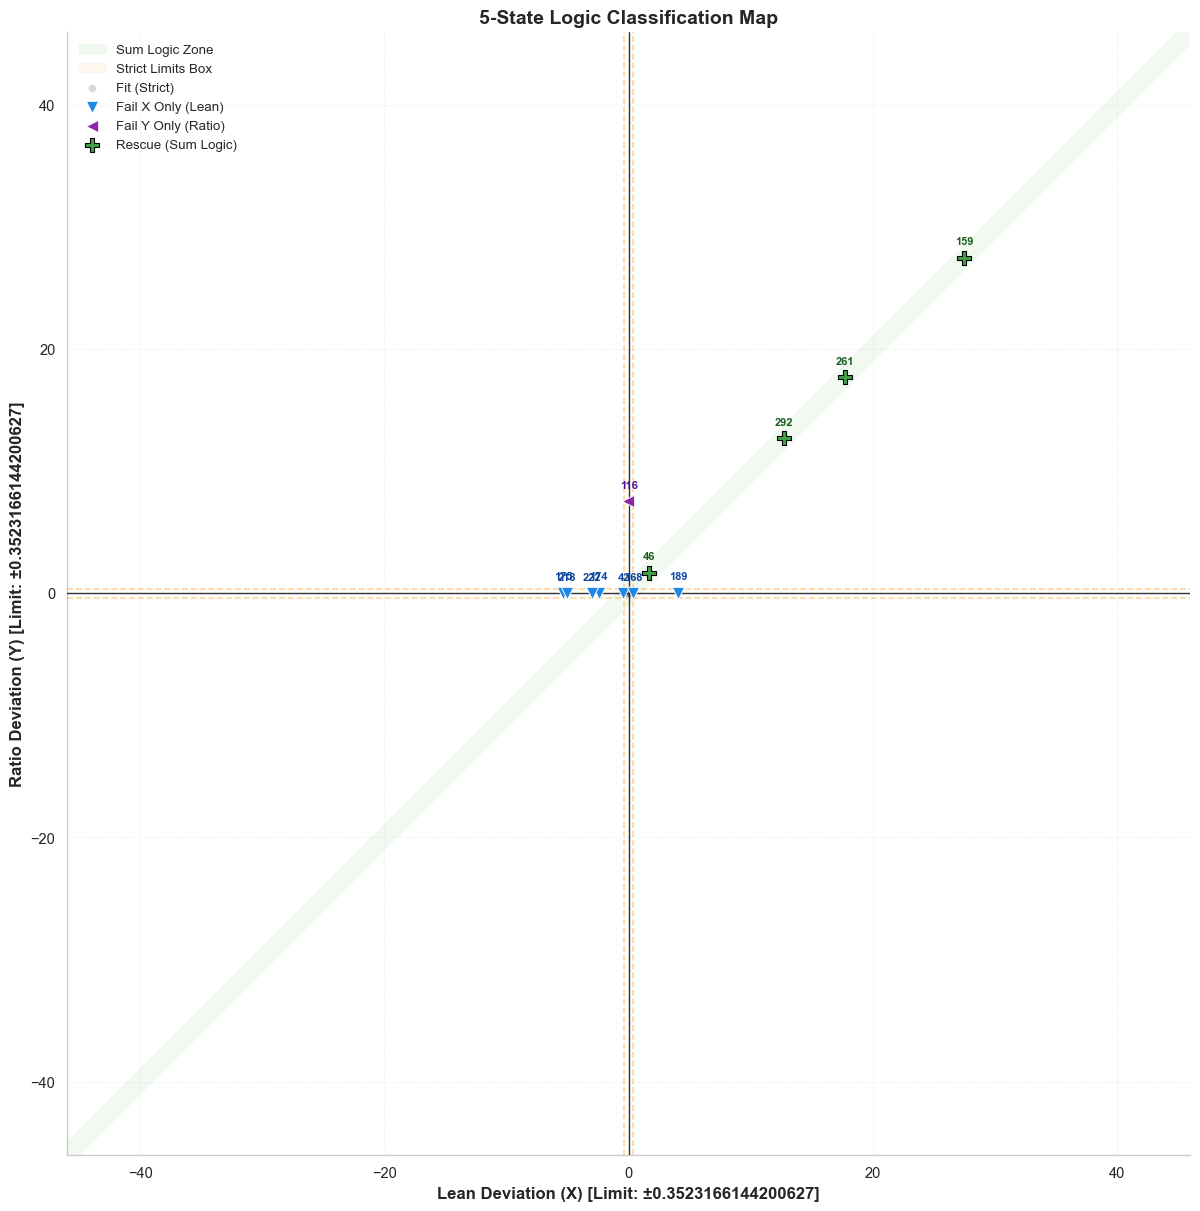

In [80]:
fig, ax = plt.subplots(figsize=(12, 12), constrained_layout=True)

# 1. DYNAMIC ZOOM (Context-Aware)
# Calculate the max extent needed to show all relevant data + limits
max_val = max(
    df_bioimpedance[col_TFC_disc_lean].abs().max(),      # Data X Max
    df_bioimpedance[col_TFC_disc_ratio].abs().max(),     # Data Y Max
    TFC_disc_lean_lim_val,                               # Limit X Boundary
    TFC_disc_ratio_lim_val,                              # Limit Y Boundary
    TFC_disc_sumOfRatio_lim_val,                         # Limit Sum Boundary
    40                                                   # Minimum visual floor (prevents zoom on empty plot)
) * 1.15  # Add 15% breathing room

# === 2. DRAW SAFETY ZONES (Background) ===

# A. Diagonal "Rescue" Zone (The Sum Limit)
# This represents the TFC_disc_sumOfRatio_lim logic
# Drawn FIRST so it sits behind the box
diag_x = np.linspace(-max_val * 2, max_val * 2, 100)
# Assuming Sum Limit is |Y - X| < Lim (Parallel to y=x)
ax.fill_between(diag_x, diag_x - TFC_disc_sumOfRatio_lim_val, diag_x + TFC_disc_sumOfRatio_lim_val,
                color='#E8F5E9', alpha=0.6, zorder=0, label='Sum Logic Zone') # Light Green

# B. The "Perfect Box" (Lean & Ratio Limits)
# Drawn SECOND to show the strict intersection
ax.fill_between([-TFC_disc_lean_lim_val, TFC_disc_lean_lim_val],
                -TFC_disc_ratio_lim_val, TFC_disc_ratio_lim_val,
                color='#FFF3E0', alpha=0.5, zorder=1, label='Strict Limits Box') # Light Orange

# Draw Boundary Lines for clarity
ax.axvline(-TFC_disc_lean_lim_val, color='#FF9800', linestyle='--', alpha=0.4)
ax.axvline(TFC_disc_lean_lim_val, color='#FF9800', linestyle='--', alpha=0.4)
ax.axhline(-TFC_disc_ratio_lim_val, color='#FF9800', linestyle='--', alpha=0.4)
ax.axhline(TFC_disc_ratio_lim_val, color='#FF9800', linestyle='--', alpha=0.4)


# === 3. PLOT THE 5 LOGIC STATES ===

def annotate_points(data_subset, color, y_offset=0):
    """Helper to label points with their ID"""
    if len(data_subset) > 0:
        for i, row in data_subset.iterrows():
            ax.text(row[col_TFC_disc_lean], row[col_TFC_disc_ratio] + y_offset,
                    f"{row.name}",
                    fontsize=8, fontweight='bold', color=color,
                    ha='center', va='bottom', zorder=20)

# 1. FIT BOTH (Perfect)
# Logic: TFC_disc_fit_lean_lim & TFC_disc_fit_ratio_lim
sns.scatterplot(data=df_bioimpedance[TFC_disc_fit_both_lim],
                x=col_TFC_disc_lean, y=col_TFC_disc_ratio,
                color='gray', alpha=0.3, s=30, label='Fit (Strict)', ax=ax, zorder=2)

# 2. FAIL LEAN ONLY (Ratio is Good)
# Logic: ~Fit_Lean & Fit_Ratio
data_fail_lean = df_bioimpedance[TFC_disc_fail_lean_lim]
sns.scatterplot(data=data_fail_lean, x=col_TFC_disc_lean, y=col_TFC_disc_ratio,
                color='#1E88E5', s=80, marker='v', label='Fail X Only (Lean)', ax=ax, zorder=4) # Blue Down Arrow
annotate_points(data_fail_lean, '#0D47A1', y_offset=max_val*0.02)

# 3. FAIL RATIO ONLY (Lean is Good)
# Logic: Fit_Lean & ~Fit_Ratio
data_fail_ratio = df_bioimpedance[TFC_disc_fail_ratio_lim]
sns.scatterplot(data=data_fail_ratio, x=col_TFC_disc_lean, y=col_TFC_disc_ratio,
                color='#8E24AA', s=80, marker='<', label='Fail Y Only (Ratio)', ax=ax, zorder=4) # Purple Left Arrow
annotate_points(data_fail_ratio, '#4A148C', y_offset=max_val*0.02)

# 4. RESCUE (SUM LOGIC)
# Logic: ~Fit_Lean & ~Fit_Ratio & Fit_Sum
# These are points outside the box, but inside the diagonal band.
data_rescue = df_bioimpedance[TFC_disc_fit_sumOfRatio_lim]
sns.scatterplot(data=data_rescue, x=col_TFC_disc_lean, y=col_TFC_disc_ratio,
                color='#43A047', s=100, marker='P', edgecolor='black', label='Rescue (Sum Logic)', ax=ax, zorder=5) # Green Plus
annotate_points(data_rescue, '#1B5E20', y_offset=max_val*0.02)

# 5. FAIL ALL (CRITICAL)
# Logic: ~Fit_Lean & ~Fit_Ratio & ~Fit_Sum
data_fail_all = df_bioimpedance[TFC_disc_fail_all_lim]
sns.scatterplot(data=data_fail_all, x=col_TFC_disc_lean, y=col_TFC_disc_ratio,
                color='#D32F2F', s=150, marker='X', edgecolor='white', linewidth=1.5, label='FAIL ALL', ax=ax, zorder=10) # Red X
annotate_points(data_fail_all, '#B71C1C', y_offset=max_val*0.03)


# === 4. FINAL POLISH ===
ax.set_aspect('equal')
ax.set_xlim(-max_val, max_val)
ax.set_ylim(-max_val, max_val)

ax.set_title("5-State Logic Classification Map", fontweight='bold', fontsize=14)
ax.set_xlabel(f"Lean Deviation (X) [Limit: ±{TFC_disc_lean_lim_val}]")
ax.set_ylabel(f"Ratio Deviation (Y) [Limit: ±{TFC_disc_ratio_lim_val}]")

# Center Crosshairs
ax.axhline(0, color='black', linewidth=1, alpha=0.8, zorder=3)
ax.axvline(0, color='black', linewidth=1, alpha=0.8, zorder=3)

ax.legend(loc='upper left', framealpha=0.95, fontsize='small')
ax.grid(True, linestyle=':', alpha=0.4)

plt.show()

In [81]:
# Fixing TFC column
col_TBFR_calc_ratio = 'TBFR_calc_ratio'
df_bioimpedance[col_TBFR_calc_ratio] = df_bioimpedance['Total Fat Content (TFC)']/df_bioimpedance['Weight'] * 100

col_TFC_fixed = 'TFC_fixed'
df_bioimpedance[col_TFC_fixed] = df_bioimpedance['Total Fat Content (TFC)']
col_TFC_fix_status = 'TFC_fixed_status'
df_bioimpedance[col_TFC_fix_status] = False

col_TBFR_fixed = 'TBFR_fixed'
df_bioimpedance[col_TBFR_fixed] = df_bioimpedance['Total Body Fat Ratio (TBFR) (%)']
col_TBFR_fix_status = 'TBFR_fixed_status'
df_bioimpedance[col_TBFR_fix_status] = False

col_LM_fixed = 'LM_fixed'
df_bioimpedance[col_LM_fixed] = df_bioimpedance['Lean Mass (LM) (%)']
col_LM_fix_status = 'LM_fixed_status'
df_bioimpedance[col_LM_fix_status] = False


col_LM_calc_sum = 'LM_calc_sum'
df_bioimpedance[col_LM_calc_sum] = 100 - df_bioimpedance['Total Body Fat Ratio (TBFR) (%)']
df_bioimpedance.loc[TFC_disc_fail_lean_lim, col_LM_fixed] = df_bioimpedance.loc[TFC_disc_fail_lean_lim,col_LM_calc_sum]
df_bioimpedance.loc[TFC_disc_fail_lean_lim, col_LM_fix_status] = True

df_bioimpedance.loc[TFC_disc_fail_ratio_lim, col_TBFR_fixed] = df_bioimpedance.loc[TFC_disc_fail_ratio_lim,col_TBFR_calc_ratio]
df_bioimpedance.loc[TFC_disc_fail_ratio_lim, col_TBFR_fix_status] = True

df_bioimpedance.loc[TFC_disc_fit_sumOfRatio_lim, col_TFC_fixed] = df_bioimpedance.loc[TFC_disc_fit_sumOfRatio_lim,col_TFC_calc_ratio]
df_bioimpedance.loc[TFC_disc_fit_sumOfRatio_lim, col_TFC_fix_status] = True

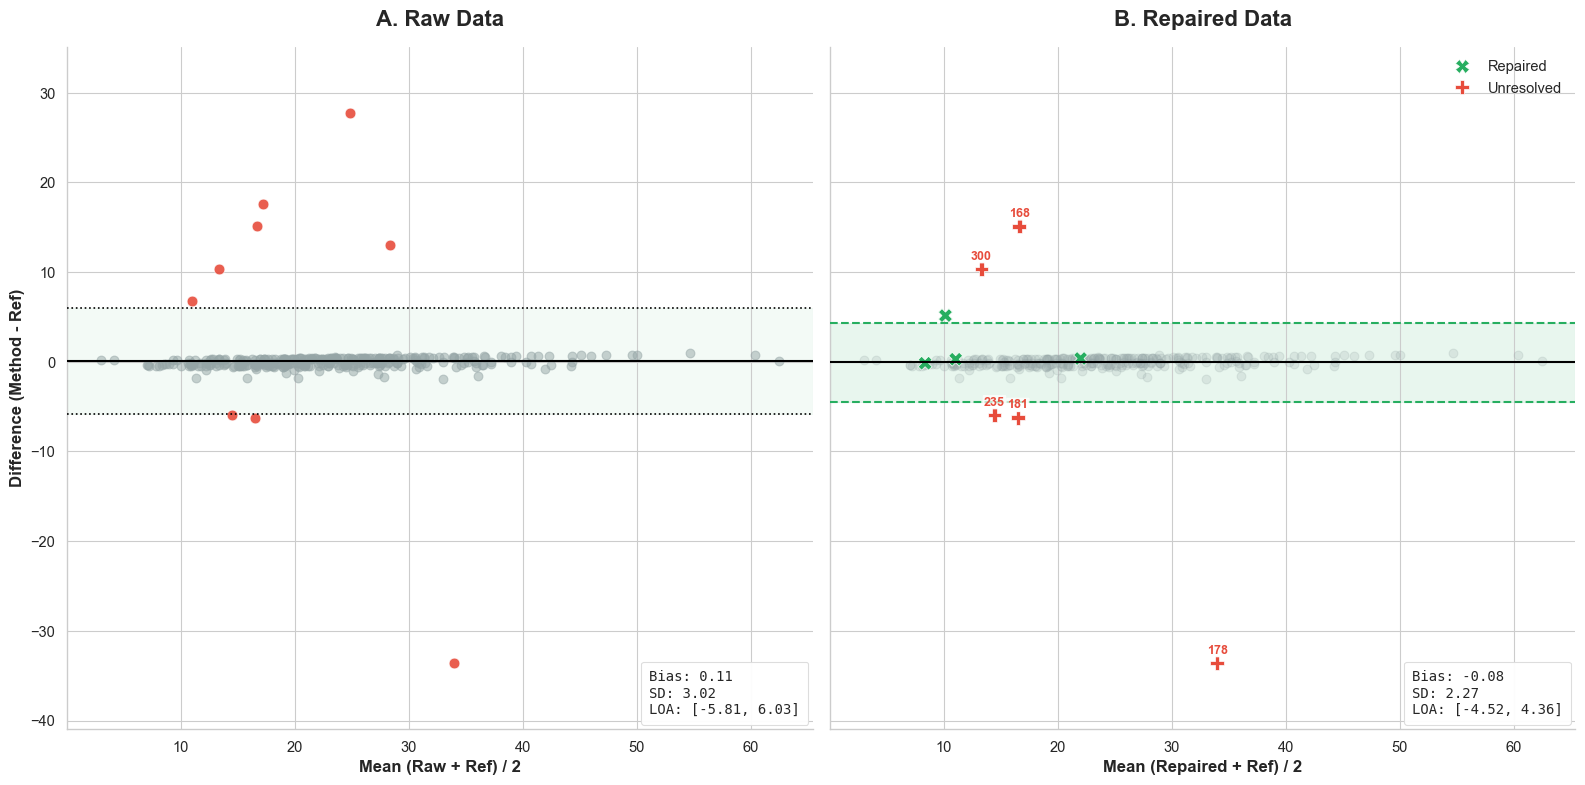

In [82]:
col_TFC_calc_4C_TBW_unfixed = 'TFC_calc_4C_TBW_unfixed'
df_bioimpedance[col_TFC_calc_4C_TBW_unfixed] = df_bioimpedance['Weight'] - df_bioimpedance['Total Body Water (TBW)'] - df_bioimpedance['Bone Mass (BM)'] - df_bioimpedance[col_TPC_calc_ratio] - epsilon_4C

col_TFC_mean_raw_TBW_unfixed = 'TFC_mean_raw_TBW_unfixed'
df_bioimpedance[col_TFC_mean_raw_TBW_unfixed] = (df_bioimpedance['Total Fat Content (TFC)'] + df_bioimpedance[col_TFC_calc_4C_TBW_unfixed]) / 2

col_TFC_diff_raw_TBW_unfixed = 'TFC_diff_raw_TBW_unfixed'
df_bioimpedance[col_TFC_diff_raw_TBW_unfixed] = df_bioimpedance['Total Fat Content (TFC)'] - df_bioimpedance[col_TFC_calc_4C_TBW_unfixed]

col_TFC_mean_fixed_TBW_unfixed = 'TFC_mean_fixed_TBW_unfixed'
df_bioimpedance[col_TFC_mean_fixed_TBW_unfixed] = (df_bioimpedance[col_TFC_fixed] + df_bioimpedance[col_TFC_calc_4C_TBW_unfixed]) / 2

col_TFC_diff_fixed_TBW_unfixed = 'TFC_diff_fixed_TBW_unfixed'
df_bioimpedance[col_TFC_diff_fixed_TBW_unfixed] = df_bioimpedance[col_TFC_fixed] - df_bioimpedance[col_TFC_calc_4C_TBW_unfixed]

_Bland_Altman_comparison(
    df_bioimpedance,
    col_TFC_mean_raw_TBW_unfixed,
    col_TFC_diff_raw_TBW_unfixed,
    col_TFC_mean_fixed_TBW_unfixed,
    col_TFC_diff_fixed_TBW_unfixed,
    col_TFC_fix_status
)

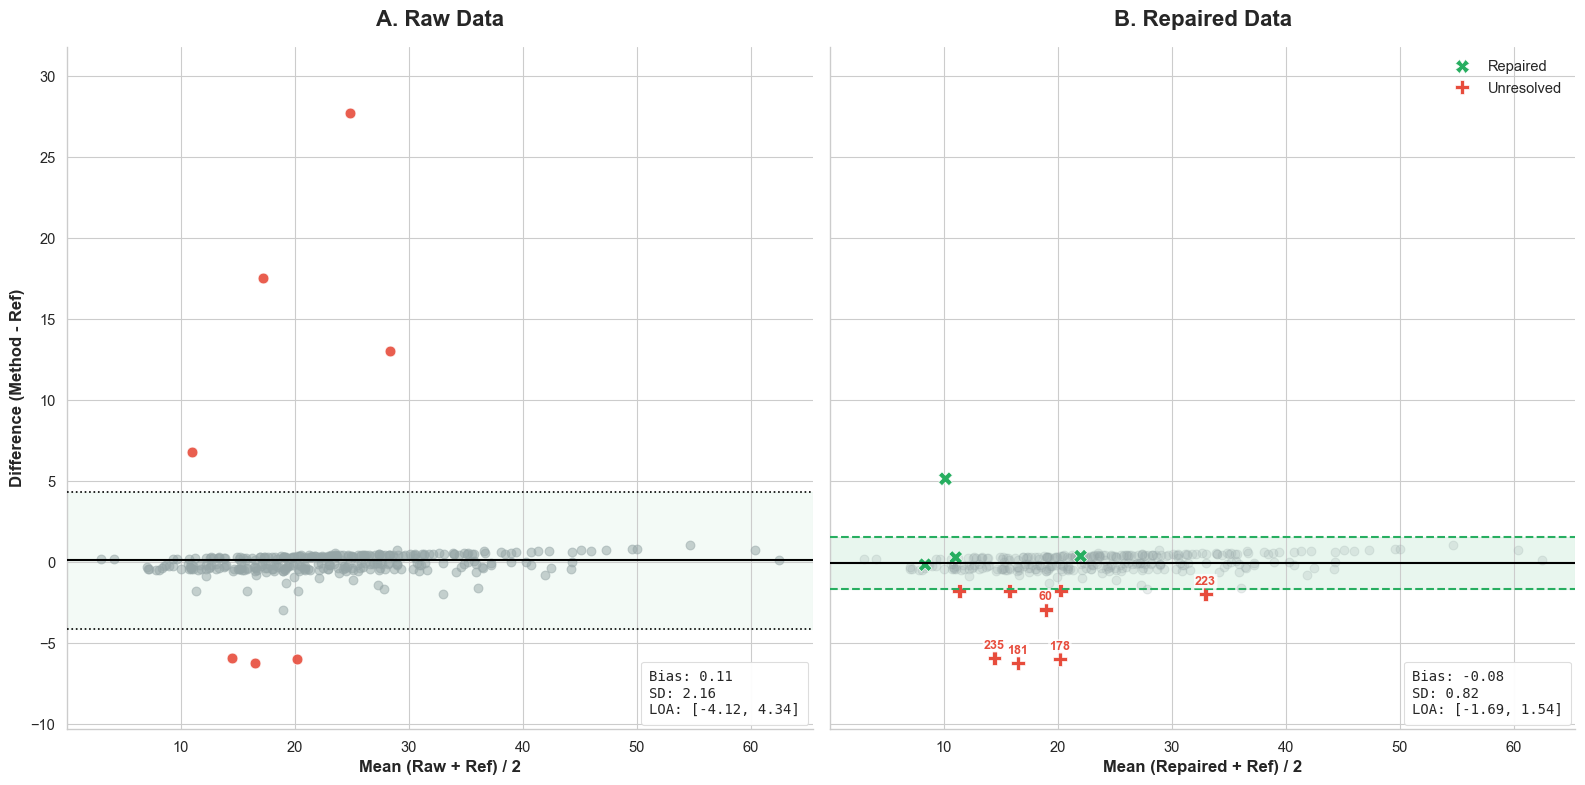

In [83]:
col_TFC_calc_4C_TBW_fixed = 'TFC_calc_4C_TBW_fixed'
df_bioimpedance[col_TFC_calc_4C_TBW_fixed] = df_bioimpedance['Weight'] - df_bioimpedance[col_TBW_fixed] - df_bioimpedance['Bone Mass (BM)'] - df_bioimpedance[col_TPC_calc_ratio] - epsilon_4C

col_TFC_mean_raw_TBW_fixed = 'TFC_mean_raw_TBW_fixed'
df_bioimpedance[col_TFC_mean_raw_TBW_fixed] = (df_bioimpedance['Total Fat Content (TFC)'] + df_bioimpedance[col_TFC_calc_4C_TBW_fixed]) / 2

col_TFC_diff_raw_TBW_fixed = 'TFC_diff_raw_TBW_fixed'
df_bioimpedance[col_TFC_diff_raw_TBW_fixed] = df_bioimpedance['Total Fat Content (TFC)'] - df_bioimpedance[col_TFC_calc_4C_TBW_fixed]

col_TFC_mean_fixed_TBW_fixed = 'TFC_mean_fixed_TBW_fixed'
df_bioimpedance[col_TFC_mean_fixed_TBW_fixed] = (df_bioimpedance[col_TFC_fixed] + df_bioimpedance[col_TFC_calc_4C_TBW_fixed]) / 2

col_TFC_diff_fixed_TBW_fixed = 'TFC_diff_fixed_TBW_fixed'
df_bioimpedance[col_TFC_diff_fixed_TBW_fixed] = df_bioimpedance[col_TFC_fixed] - df_bioimpedance[col_TFC_calc_4C_TBW_fixed]

_Bland_Altman_comparison(
    df_bioimpedance,
    col_TFC_mean_raw_TBW_fixed,
    col_TFC_diff_raw_TBW_fixed,
    col_TFC_mean_fixed_TBW_fixed,
    col_TFC_diff_fixed_TBW_fixed,
    col_TFC_fix_status
)

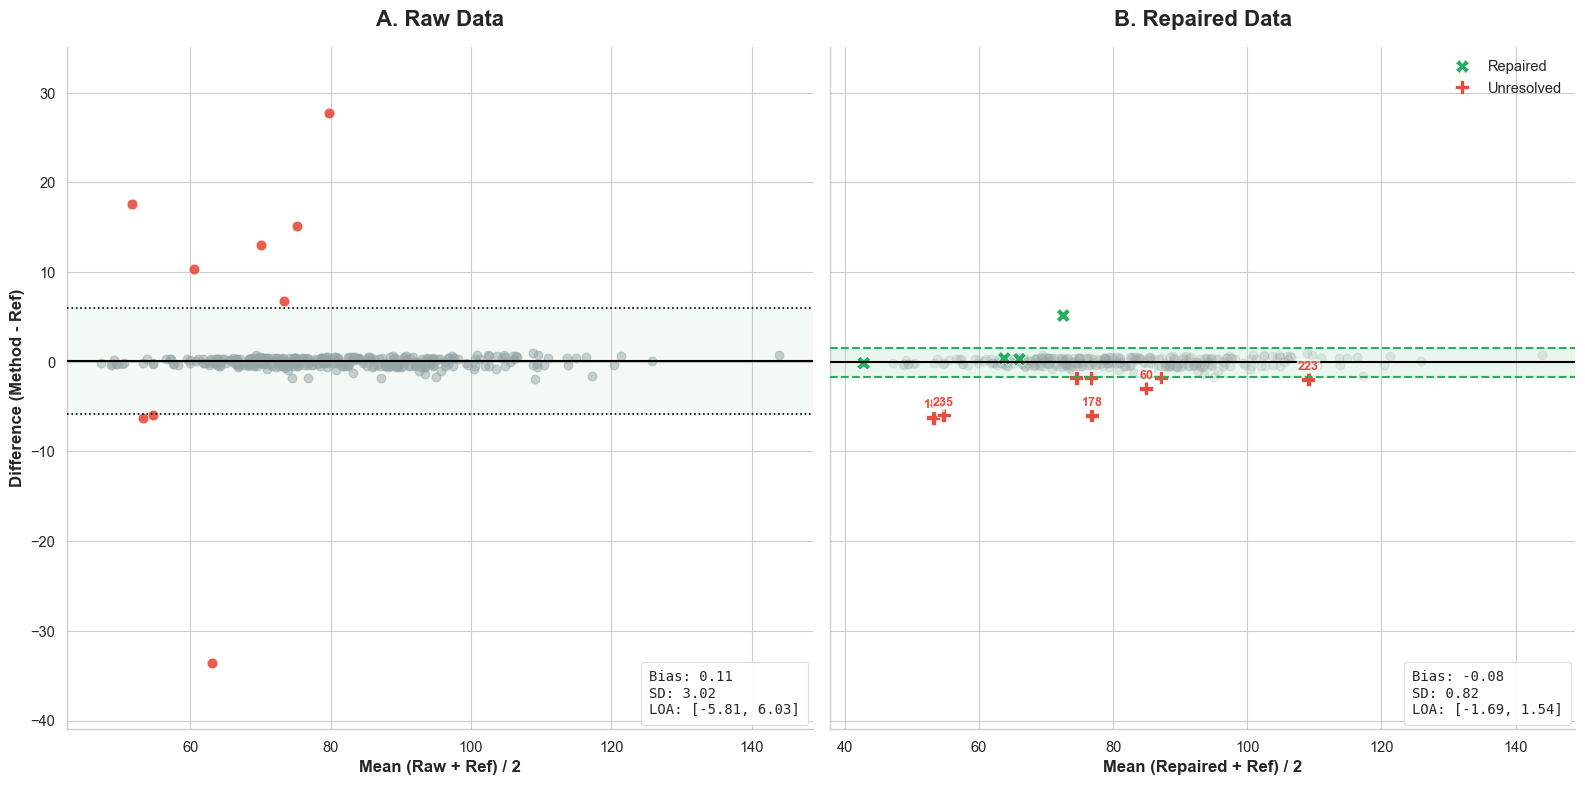

In [84]:
# ==========================================
# 1. Define the Sums (Method)
# ==========================================

# A. Original Sum (Raw TBW + Raw TFC + Constants)
col_Sum_Original = 'Sum_Components_Original'
df_bioimpedance[col_Sum_Original] = (
    df_bioimpedance['Total Body Water (TBW)'] +
    df_bioimpedance['Total Fat Content (TFC)'] +
    df_bioimpedance['Bone Mass (BM)'] +
    df_bioimpedance[col_TPC_calc_ratio] +
    epsilon_4C
)

# B. Fixed Sum (Fixed TBW + Fixed TFC + Constants)
col_Sum_Fixed = 'Sum_Components_Fixed'
df_bioimpedance[col_Sum_Fixed] = (
    df_bioimpedance[col_TBW_fixed] +
    df_bioimpedance[col_TFC_fixed] +
    df_bioimpedance['Bone Mass (BM)'] +
    df_bioimpedance[col_TPC_calc_ratio] +
    epsilon_4C
)

# ==========================================
# 2. Prepare Bland-Altman Vectors
# ==========================================

# --- Panel A: Raw Sum vs Weight ---
col_Mean_Raw_Weight = 'Mean_SumRaw_Weight'
# Mean = (Sum + Weight) / 2
df_bioimpedance[col_Mean_Raw_Weight] = (df_bioimpedance[col_Sum_Original] + df_bioimpedance['Weight']) / 2

col_Diff_Raw_Weight = 'Diff_SumRaw_Weight'
# Difference = Method (Sum) - Reference (Weight)
df_bioimpedance[col_Diff_Raw_Weight] = df_bioimpedance[col_Sum_Original] - df_bioimpedance['Weight']

# --- Panel B: Fixed Sum vs Weight ---
col_Mean_Fixed_Weight = 'Mean_SumFixed_Weight'
df_bioimpedance[col_Mean_Fixed_Weight] = (df_bioimpedance[col_Sum_Fixed] + df_bioimpedance['Weight']) / 2

col_Diff_Fixed_Weight = 'Diff_SumFixed_Weight'
df_bioimpedance[col_Diff_Fixed_Weight] = df_bioimpedance[col_Sum_Fixed] - df_bioimpedance['Weight']

# ==========================================
# 3. Execute Comparison
# ==========================================
_Bland_Altman_comparison(
    df_bioimpedance,
    col_Mean_Raw_Weight,    # Panel A X-axis
    col_Diff_Raw_Weight,    # Panel A Y-axis
    col_Mean_Fixed_Weight,  # Panel B X-axis
    col_Diff_Fixed_Weight,  # Panel B Y-axis
    col_TFC_fix_status      # Coloring Logic
)